In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
import yfinance as yf
import os

pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"yfinance   : {yf.__version__}")
print(f"scipy      : {scipy.__version__}")

pandas     : 3.0.1
numpy      : 2.4.2
yfinance   : 1.2.0
scipy      : 1.17.1


In [2]:
ticker = ["AAPL", "MSFT", "JPM", "SPY"]
weight = np.array([0.3, 0.3, 0.2, 0.2])

start_date = "2020-01-01"
end_date = "2023-12-31"

print(f"Portfolio : {ticker}")
print(f"Weights   : {weight}")
print(f"Period    : {start_date} → {end_date}")
print(f"Weights sum: {weight.sum()}") 

Portfolio : ['AAPL', 'MSFT', 'JPM', 'SPY']
Weights   : [0.3 0.3 0.2 0.2]
Period    : 2020-01-01 → 2023-12-31
Weights sum: 1.0


In [3]:
r_data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

price = r_data["Close"]

print(f"\nShape       : {price.shape} (rows=trading days, cols=stocks)")
print(f"Date range    : {price.index[0].date()} → {price.index[-1].date()}")
print(f"Missing values: {price.isnull().sum().sum()}")

price.head()

[*********************100%***********************]  4 of 4 completed


Shape       : (1006, 4) (rows=trading days, cols=stocks)
Date range    : 2020-01-02 → 2023-12-29
Missing values: 0


Ticker,AAPL,JPM,MSFT,SPY
Date,,,,
2020-01-02,72.4005,119.0364,152.1584,297.6990
2020-01-03,71.6966,117.4656,150.2637,295.4448
2020-01-06,72.2679,117.3722,150.6522,296.5718
2020-01-07,71.9281,115.3768,149.2786,295.7379
2020-01-08,73.0851,116.2768,151.6563,297.3141


In [4]:
price.to_csv("../data/price.csv")
print("Prices saved to data/prices.csv")

Prices saved to data/prices.csv


### Daily Percentage Returns ###

In [5]:
daily_r = price.pct_change().dropna()

print(f"Shape: {daily_r.shape}")
print(f"\nSample statistics:")
daily_r.describe().round(4)

Shape: (1005, 4)

Sample statistics:


Ticker,AAPL,JPM,MSFT,SPY
count,1005.0000,1005.0000,1005.0000,1005.0000
mean,0.0012,0.0005,0.0011,0.0005
std,0.0211,0.0217,0.0205,0.0143
min,-0.1286,-0.1496,-0.1474,-0.1094
25%,-0.0091,-0.0099,-0.0094,-0.0057
50%,0.0010,0.0003,0.0010,0.0008
75%,0.0127,0.0106,0.0120,0.0076
max,0.1198,0.1801,0.1422,0.0906


### Weighted Portfolio Returns ###

In [6]:
portfolio_r = daily_r.dot(weight)
portfolio_r.name = "Portfolio"

print(f"Total trading days : {len(portfolio_r)}")
print(f"Mean daily return  : {portfolio_r.mean():.4f}")
print(f"Std daily return   : {portfolio_r.std():.4f}")
print(f"Min daily return   : {portfolio_r.min():.4f}  ← worst day")
print(f"Max daily return   : {portfolio_r.max():.4f}  ← best day")

Total trading days : 1005
Mean daily return  : 0.0008
Std daily return   : 0.0169
Min daily return   : -0.1349  ← worst day
Max daily return   : 0.1355  ← best day


### Portfolio Returns Over Time ###

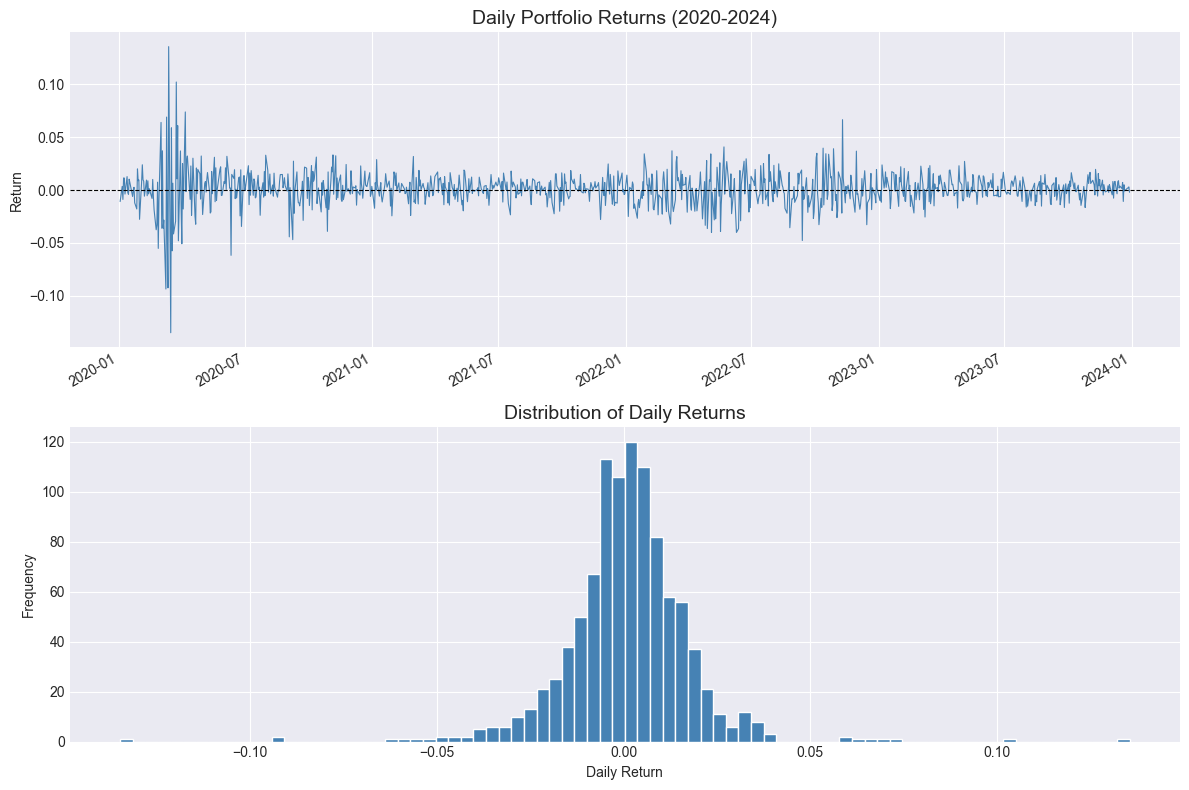

Plot saved


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

portfolio_r.plot(ax=axes[0], color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Daily Portfolio Returns (2020-2024)", fontsize=14)
axes[0].set_ylabel("Return")
axes[0].set_xlabel("")

portfolio_r.hist(ax=axes[1], bins=80, color="steelblue", edgecolor="white")
axes[1].set_title("Distribution of Daily Returns", fontsize=14)
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../data/phase2_returns_plot.png", dpi=150)
plt.show()
print("Plot saved")

### Individual Stock Returns vs Portfolio ###

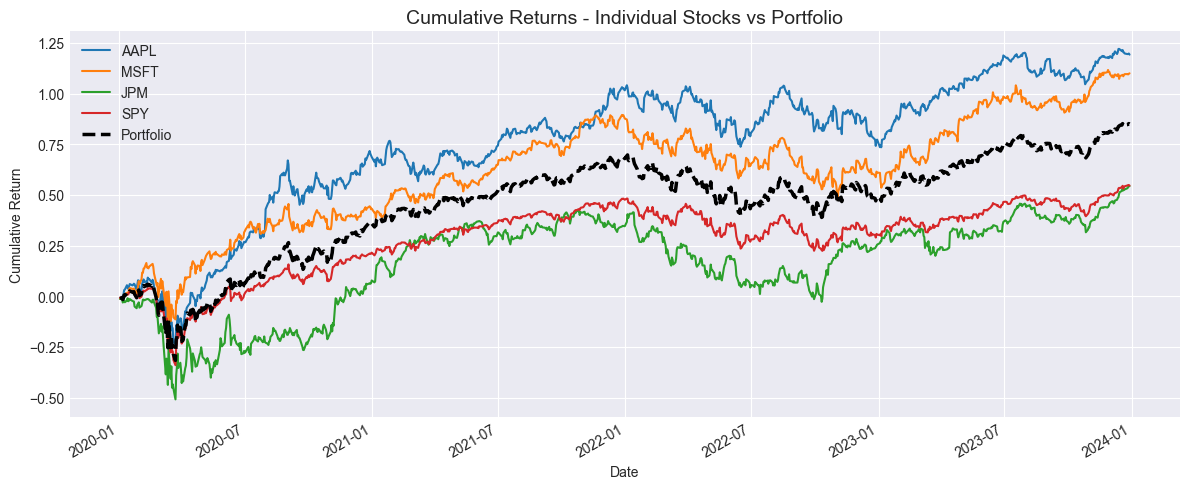

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

for ticker in ticker:
    daily_r[ticker].cumsum().plot(ax=ax, label=ticker, linewidth=1.5)

portfolio_r.cumsum().plot(ax=ax, label="Portfolio",
                          linewidth=2.5, linestyle="--", color="black")

ax.set_title("Cumulative Returns - Individual Stocks vs Portfolio", fontsize=14)
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()

### Historical VaR ###

In [9]:
confi_level = 0.95

historical_var = np.percentile(portfolio_r, (1 - confi_level) * 100)

print("=" * 45)
print("       HISTORICAL VaR RESULTS (95%)")
print("=" * 45)
print(f"  Confidence Level : {confi_level * 100:.0f}%")
print(f"  Hisotrical VaR   : {historical_var:.4f}  ({historical_var*100:.2f}%)")
print(f"  Interpretation   :  On a typical day, your")
print(f"  portfolio will NOT lose more than")
print(f"  {abs(historical_var)*100:.2f}% with 95% confidence")
print("=" * 45)

       HISTORICAL VaR RESULTS (95%)
  Confidence Level : 95%
  Hisotrical VaR   : -0.0238  (-2.38%)
  Interpretation   :  On a typical day, your
  portfolio will NOT lose more than
  2.38% with 95% confidence


### Dollar Amount ###

In [10]:
portfolio_v = 100000

dollar_var = portfolio_v * abs(historical_var)

print(f"  Portfolio Value  : ${portfolio_v:,.0f}")
print(f"  Historical VaR   : {historical_var*100:.2f}%")
print(f"  Dollar VaR       : ${dollar_var:,.2f}")
print(f"\n  → On a bad day (1-in-20), you could")
print(f"    lose up to ${dollar_var:,.2f} from your portfolio")

  Portfolio Value  : $100,000
  Historical VaR   : -2.38%
  Dollar VaR       : $2,377.65

  → On a bad day (1-in-20), you could
    lose up to $2,377.65 from your portfolio


### Calculate CVaR (Expected Shortfall) ###

In [11]:
cvar = portfolio_r[portfolio_r <= historical_var].mean()
dollar_cvar = portfolio_v * abs(cvar)

print("=" * 45)
print("       CVaR RESULTS (Expected Shortfall)")
print("=" * 45)
print(f"  CVaR (95%)       : {cvar:.4f}  ({cvar*100:.2f}%)")
print(f"  Dollar CVaR      : ${dollar_cvar:,.2f}")
print(f"\n  → On the WORST 5% of days, your average")
print(f"    loss would be ${dollar_cvar:,.2f}")
print("=" * 45)

       CVaR RESULTS (Expected Shortfall)
  CVaR (95%)       : -0.0388  (-3.88%)
  Dollar CVaR      : $3,883.48

  → On the WORST 5% of days, your average
    loss would be $3,883.48


### Visualize Historical VaR ###

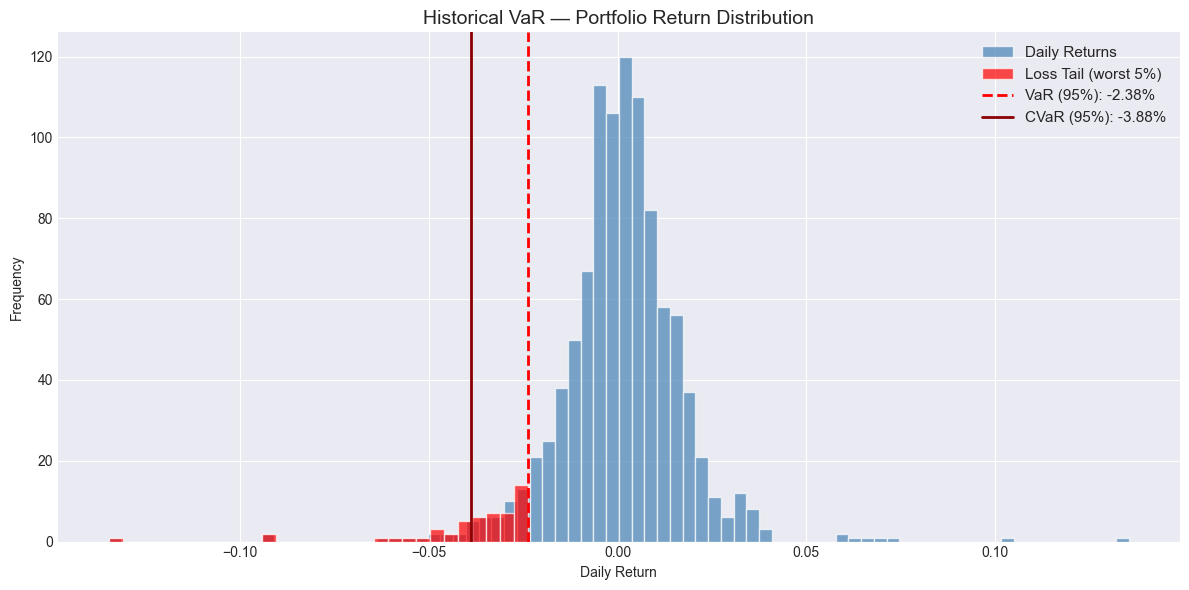

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

portfolio_r.hist(ax=ax, bins=80, color="steelblue", 
                  edgecolor="white", alpha=0.7, label="Daily Returns")

tai_returns = portfolio_r[portfolio_r <= historical_var]
tai_returns.hist(ax=ax, bins=30, color="red", 
                   edgecolor="white", alpha=0.7, label="Loss Tail (worst 5%)")

ax.axvline(historical_var, color="red", linewidth=2, 
            linestyle="--", label=f"VaR (95%): {historical_var*100:.2f}%")

ax.axvline(cvar, color="darkred", linewidth=2, 
            linestyle="-", label=f"CVaR (95%): {cvar*100:.2f}%")

ax.set_title("Historical VaR — Portfolio Return Distribution", fontsize=14)
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../data/phase3_historical_var.png", dpi=150)
plt.show()

### Identify Actual Breach Days ###

In [13]:
b_days = portfolio_r[portfolio_r <= historical_var].sort_values()

print(f"Total trading days : {len(portfolio_r)}")
print(f"VaR breach days    : {len(b_days)}")
print(f"Breach rate        : {len(b_days)/len(portfolio_r)*100:.1f}%")
print(f"\nTop 10 worst days:")
print("-" * 35)

for date, ret in b_days.head(10).items():
    print(f"  {date.date()}  →  {ret*100:.2f}%  (${portfolio_v*abs(ret):,.0f} loss)")

Total trading days : 1005
VaR breach days    : 51
Breach rate        : 5.1%

Top 10 worst days:
-----------------------------------
  2020-03-16  →  -13.49%  ($13,485 loss)
  2020-03-09  →  -9.35%  ($9,354 loss)
  2020-03-12  →  -9.25%  ($9,246 loss)
  2020-06-11  →  -6.17%  ($6,171 loss)
  2020-03-18  →  -5.75%  ($5,747 loss)
  2020-02-27  →  -5.52%  ($5,517 loss)
  2020-04-01  →  -5.08%  ($5,078 loss)
  2020-03-27  →  -4.80%  ($4,796 loss)
  2022-09-13  →  -4.77%  ($4,772 loss)
  2020-09-08  →  -4.69%  ($4,691 loss)


### Rolling 30-day VaR ###

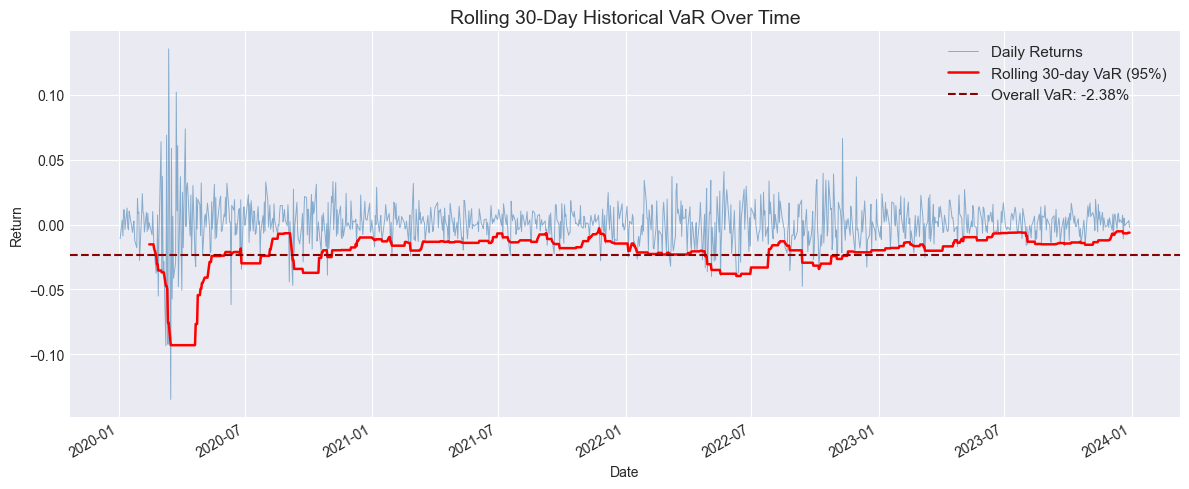

In [14]:
roll_var = portfolio_r.rolling(window=30).quantile(0.05)

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_r.plot(ax=ax, color="steelblue", linewidth=0.7, 
                  alpha=0.6, label="Daily Returns")

roll_var.plot(ax=ax, color="red", linewidth=1.8, 
                  label="Rolling 30-day VaR (95%)")

ax.axhline(historical_var, color="darkred", linewidth=1.5,
            linestyle="--", label=f"Overall VaR: {historical_var*100:.2f}%")

ax.set_title("Rolling 30-Day Historical VaR Over Time", fontsize=14)
ax.set_ylabel("Return")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../data/phase3_rolling_var.png", dpi=150)
plt.show()

### Parametric VaR ###


In [15]:
from scipy.stats import norm

mu    = portfolio_r.mean()
sigma = portfolio_r.std()

z_scr = norm.ppf(1 - confi_level)

para_var = mu + z_scr * sigma

print("=" * 45)
print("      PARAMETRIC VaR RESULTS (95%)")
print("=" * 45)
print(f"   Mean daily return : {mu:.6f}")
print(f"   Std dev (sigma)   : {sigma:.6f}")
print(f"   Z-score (95%)     : {z_scr:.4f}")
print(f"   Parametric VaR    : {para_var:.4f} ({para_var*100:.2f}%)")
print(f"   Dollar VaR        : ${portfolio_v * abs(para_var):,.2f}")
print("=" * 45)

      PARAMETRIC VaR RESULTS (95%)
   Mean daily return : 0.000846
   Std dev (sigma)   : 0.016909
   Z-score (95%)     : -1.6449
   Parametric VaR    : -0.0270 (-2.70%)
   Dollar VaR        : $2,696.65


### Parametric CVaR ###

In [16]:
para_cvar    = mu - sigma * norm.pdf(z_scr) / (1 - confi_level)
dollar_pcvar = portfolio_v * abs(para_cvar)

print("=" * 45)
print("      PARAMETRIC CVaR RESULTS (95%)")
print("=" * 45)
print(f"  Parametric CVaR  : {para_cvar:.4f} ({para_cvar*100:.2f}%)")
print(f"  Dollar CVaR      : ${dollar_pcvar:,.2f}")
print("=" * 45)

      PARAMETRIC CVaR RESULTS (95%)
  Parametric CVaR  : -0.0340 (-3.40%)
  Dollar CVaR      : $3,403.19


### Normality Test ###

In [17]:
from scipy.stats import shapiro, jarque_bera, skew, kurtosis

sample        = portfolio_r.sample(min(500, len(portfolio_r)), random_state=42)
stat_sw, p_sw = shapiro(sample)

stat_jb, p_jb = jarque_bera(portfolio_r)

skewness      = skew(portfolio_r)
kurt          = kurtosis(portfolio_r) 

print("=" * 45)
print("         NORMALITY TEST RESULTS")
print("=" * 45)
print(f"  Shapiro-Wilk  stat : {stat_sw:.4f}")
print(f"  Shapiro-Wilk  p    : {p_sw:.6f}")
print(f"  Jarque-Bera   stat : {stat_jb:.4f}")
print(f"  Jarque-Bera   p    : {p_jb:.6f}")
print("=" * 45)
print(f"  Skewness           : {skewness:.4f}  (normal = 0)")
print(f"  Excess Kurtosis    : {kurt:.4f}   (normal = 0)")
print("=" * 45)

if p_sw < 0.05:
    print("   Returns are NOT normally distributed")
    print("   → Parametric VaR assumption holds")
print("=" * 45)

         NORMALITY TEST RESULTS
  Shapiro-Wilk  stat : 0.8940
  Shapiro-Wilk  p    : 0.000000
  Jarque-Bera   stat : 5855.9128
  Jarque-Bera   p    : 0.000000
  Skewness           : -0.0974  (normal = 0)
  Excess Kurtosis    : 11.8239   (normal = 0)
   Returns are NOT normally distributed
   → Parametric VaR assumption holds


### Q-Q Plot (Visual Normality Check) ###

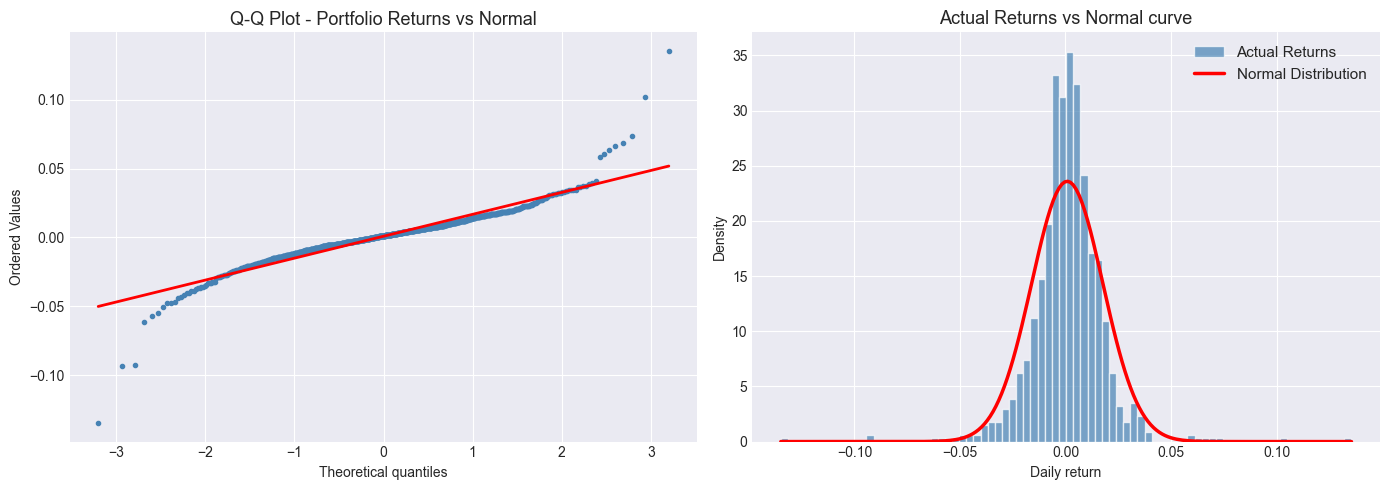

In [18]:
from scipy.stats import probplot

fig,axes = plt.subplots(1,2, figsize=(14,5))

probplot(portfolio_r, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot - Portfolio Returns vs Normal", fontsize=13)
axes[0].get_lines()[0].set(color="steelblue", markersize=3)
axes[0].get_lines()[1].set(color="red", linewidth=2)

x = np.linspace(portfolio_r.min(), portfolio_r.max(), 200)
normal_curve = norm.pdf(x, mu, sigma)

axes[1].hist(portfolio_r, bins=80, density=True,
             color="steelblue", edgecolor="white",
             alpha=0.7, label="Actual Returns")
axes[1].plot(x, normal_curve, color="red",
             linewidth=2.5, label="Normal Distribution")
axes[1].set_title("Actual Returns vs Normal curve", fontsize=13)
axes[1].set_xlabel("Daily return")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("../data/phase4_normality.png", dpi=150)
plt.show()

### Side by Side Comparison ###

In [19]:
print("=" * 55)
print("         VaR COMPARISON - HISTORICAL vs PARAMETRIC")
print("=" * 55)
print(f"  {'Metric':<25} {'Historical':>12} {'Parametric':>12}")
print("-" * 55)
print(f"  {'VaR (95%)':<25} {historical_var*100:>11.2f}% {para_var*100:>11.2f}%")
print(f"  {'CVaR (95%)':<25} {cvar*100:>11.2f}% {para_cvar*100:11.2f}%")
print(f"  {'Dollar VaR ($100k)':<25} ${portfolio_v*abs(historical_var):>10,.2f} ${portfolio_v*abs(para_var):>10,.2f}")
print("=" * 55)

diff = abs(historical_var) - abs(para_var)
if diff > 0:
    print(f"\n   Historical VaR is HIGHER by {abs(diff)*100:.2f}%")
    print(f"     Parametric method UNDERESTIMATES risk")
    print(f"     Reason: real returns have fatter tails than normal")
else:
    print(f"\n  Parametric VaR is HIGHER by {abs(diff)*100:.2f}%")
    print(f"     Parametric method OVERESTIMATES risk")
    

         VaR COMPARISON - HISTORICAL vs PARAMETRIC
  Metric                      Historical   Parametric
-------------------------------------------------------
  VaR (95%)                       -2.38%       -2.70%
  CVaR (95%)                      -3.88%       -3.40%
  Dollar VaR ($100k)        $  2,377.65 $  2,696.65

  Parametric VaR is HIGHER by 0.32%
     Parametric method OVERESTIMATES risk


### Visual Comparison Plot ###

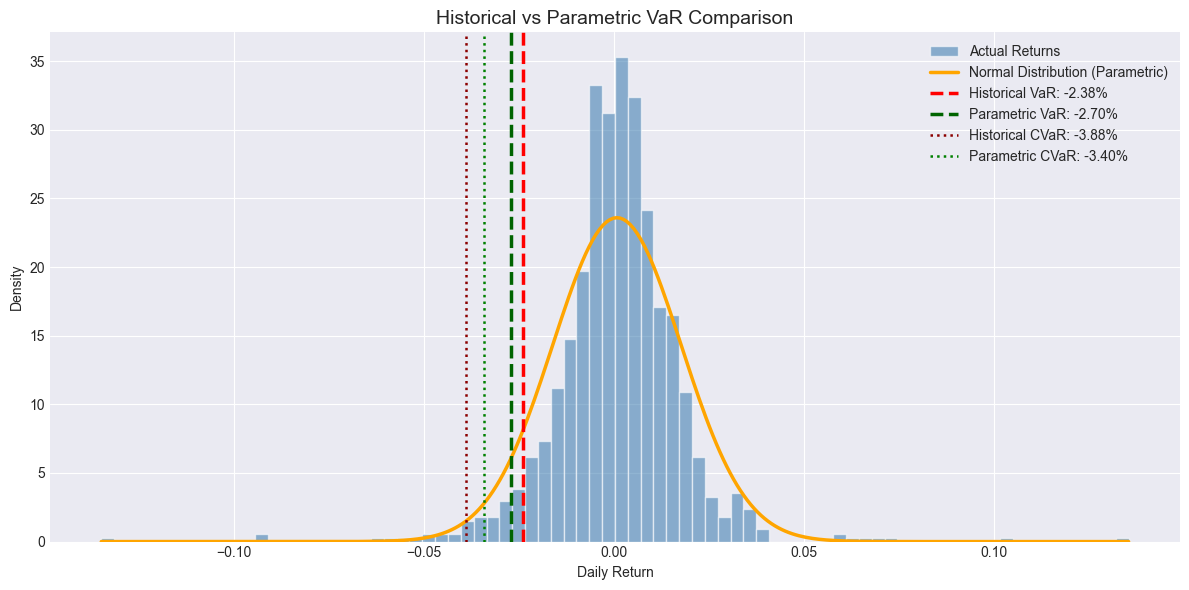

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(portfolio_r.min(), portfolio_r.max(), 300)

ax.hist(portfolio_r, bins=80, density=True,
         color="steelblue", edgecolor="white",
         alpha=0.6, label="Actual Returns")

ax.plot(x, norm.pdf(x, mu, sigma), color="orange",
         linewidth=2.5, label="Normal Distribution (Parametric)")

ax.axvline(historical_var, color="red", linewidth=2.5,
            linestyle="--", label=f"Historical VaR: {historical_var*100:.2f}%")

ax.axvline(para_var, color="darkgreen", linewidth=2.5,
            linestyle="--", label=f"Parametric VaR: {para_var*100:.2f}%")

ax.axvline(cvar, color="darkred", linewidth=1.8,
            linestyle=":", label=f"Historical CVaR: {cvar*100:.2f}%")
ax.axvline(para_cvar, color="green", linewidth=1.8,
            linestyle=":", label=f"Parametric CVaR: {para_cvar*100:.2f}%")

ax.set_title("Historical vs Parametric VaR Comparison", fontsize=14)
ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../data/phase4_var_comparison.png", dpi=150)
plt.show()

### Final Summary ###

In [21]:
print("=" * 55)
print("              PROJECT SUMMARY")
print("=" * 55)
print(f"  Portfolio         : {ticker}")
print(f"  Weights           : {weight}")
print(f"  Period            : {start_date} → {end_date}")
print(f"  Trading days      : {len(portfolio_r)}")
print(f"  Portfolio Value   : ${portfolio_v:,}")
print("=" * 55)
print(f"  Mean daily ret    : {mu*100:.4f}%")
print(f"  Daily volatility  : {sigma*100:.4f}%")
print(f"  Skewness          : {skewness:.4f}")
print(f"  Excess Kurtosis   : {kurt:.4f}")
print("=" * 55)
print(f"  Historical VaR    : {historical_var*100:.2f}%  (${portfolio_v*abs(historical_var):,.2f})")
print(f"  Parametric VaR    : {para_var*100:.2f}%  (${portfolio_v*abs(para_var):,.2f})")
print(f"  Historical CVaR   : {cvar*100:.2f}%  (${portfolio_v*abs(cvar):,.2f})")
print(f"  Parametric CVaR   : {para_cvar*100:.2f}%  (${dollar_pcvar:,.2f})")
print("=" * 55)

              PROJECT SUMMARY
  Portfolio         : SPY
  Weights           : [0.3 0.3 0.2 0.2]
  Period            : 2020-01-01 → 2023-12-31
  Trading days      : 1005
  Portfolio Value   : $100,000
  Mean daily ret    : 0.0846%
  Daily volatility  : 1.6909%
  Skewness          : -0.0974
  Excess Kurtosis   : 11.8239
  Historical VaR    : -2.38%  ($2,377.65)
  Parametric VaR    : -2.70%  ($2,696.65)
  Historical CVaR   : -3.88%  ($3,883.48)
  Parametric CVaR   : -3.40%  ($3,403.19)


### Backtesting VaR ###

In [22]:
t_days       = len(portfolio_r)
exp_breach_r = 1 - confi_level

hist_breaches = (portfolio_r < historical_var).sum()
hist_rate     = hist_breaches / t_days

param_breaches = (portfolio_r < para_var).sum()
param_rate     = param_breaches / t_days

print("=" * 55)
print("             VaR BACKTESTING RESULTS")
print("=" * 55)
print(f"  Total Trading Days     : {t_days}")
print(f"  Expected Breach Rate   : {exp_breach_r*100:.1f}%")
print(f"  Expected Breach Days   : {int(t_days * exp_breach_r)}")
print("=" * 55)
print(f"  Historical VaR Breaches: {hist_breaches} days ({hist_rate*100:.2f}%)")
print(f"  Parametric Var Breaches: {param_breaches} days ({param_rate*100:.2f}%)")
print("=" * 55)

if abs (hist_rate - exp_breach_r) < 0.01:
    print("  Historical VaR model is well-calibrated")
else: 
    print(f" Historical VaR breach rate deviates by {abs(hist_rate - exp_breach_r)*100:.2f}%")

if abs(param_rate - exp_breach_r) < 0.01:
    print("  Parametric VaR model is well-calibrated")
else:
    print(f"  Parametric VaR breach rate deviates by {abs(param_rate - exp_breach_r)*100:.2f}%")
print("=" * 55)

             VaR BACKTESTING RESULTS
  Total Trading Days     : 1005
  Expected Breach Rate   : 5.0%
  Expected Breach Days   : 50
  Historical VaR Breaches: 51 days (5.07%)
  Parametric Var Breaches: 39 days (3.88%)
  Historical VaR model is well-calibrated
  Parametric VaR breach rate deviates by 1.12%


### Monte Carlo VaR (third method) ###

In [23]:
np.random.seed(42)
n_simulations = 10000

simulated_r = np.random.normal(mu, sigma, n_simulations)

mc_var  = np.percentile(simulated_r, (1 - confi_level) * 100) 
mc_cvar = simulated_r [simulated_r <= mc_var].mean()

print("=" * 45)
print("       MONTE CARLO VaR RESULTS (95%)")
print("=" * 45)
print(f"  Simulations      : {n_simulations:,}")
print(f"  MC VaR (95%)     : {mc_var:.4f} ({mc_var*100:.2f}%)")
print(f"  MC CVaR (95%)    : {mc_cvar:.4f} ({mc_cvar*100:.2f}%)")
print(f"  Dollar VaR       : ${portfolio_v * abs(mc_var):,.2f}")
print(f"  Dollar CVaR      : ${portfolio_v * abs(mc_cvar):,.2f}")
print("=" * 45)

       MONTE CARLO VaR RESULTS (95%)
  Simulations      : 10,000
  MC VaR (95%)     : -0.0271 (-2.71%)
  MC CVaR (95%)    : -0.0342 (-3.42%)
  Dollar VaR       : $2,713.56
  Dollar CVaR      : $3,424.60


### All Three Methods Compared ###

In [24]:
print("=" * 60)
print("        COMPLETE VaR COMPARISON — ALL THREE METHODS")
print("=" * 60)
print(f"  {'Metric':<28} {'Historical':>9} {'Parametric':>9} {'Monte Carlo':>9}")
print("-" * 60)
print(f"  {'VaR (95%)':<28} {historical_var*100:>8.2f}% {para_var*100:>8.2f}% {mc_var*100:>8.2f}%")
print(f"  {'CVaR (95%)':<28} {cvar*100:>8.2f}% {para_cvar*100:>8.2f}% {mc_cvar*100:>8.2f}%")
print(f"  {'Dollar VaR ($100k)':<28} ${portfolio_v*abs(historical_var):>8,.0f} ${portfolio_v*abs(para_var):>8,.0f} ${portfolio_v*abs(mc_var):>8,.0f}")
print(f"  {'Dollar CVaR ($100k)':<28} ${portfolio_v*abs(cvar):>8,.0f} ${dollar_pcvar:>8,.0f} ${portfolio_v*abs(mc_cvar):>8,.0f}")
print(f"  {'Breach Days (actual)':<28} {hist_breaches:>9} {param_breaches:>9} {'N/A':>9}")
print(f"  {'Breach Rate':<28} {hist_rate*100:>8.2f}% {param_rate*100:>8.2f}% {'N/A':>9}")
print("=" * 60)

        COMPLETE VaR COMPARISON — ALL THREE METHODS
  Metric                       Historical Parametric Monte Carlo
------------------------------------------------------------
  VaR (95%)                       -2.38%    -2.70%    -2.71%
  CVaR (95%)                      -3.88%    -3.40%    -3.42%
  Dollar VaR ($100k)           $   2,378 $   2,697 $   2,714
  Dollar CVaR ($100k)          $   3,883 $   3,403 $   3,425
  Breach Days (actual)                51        39       N/A
  Breach Rate                      5.07%     3.88%       N/A


### Final Visualization (all methods) ###

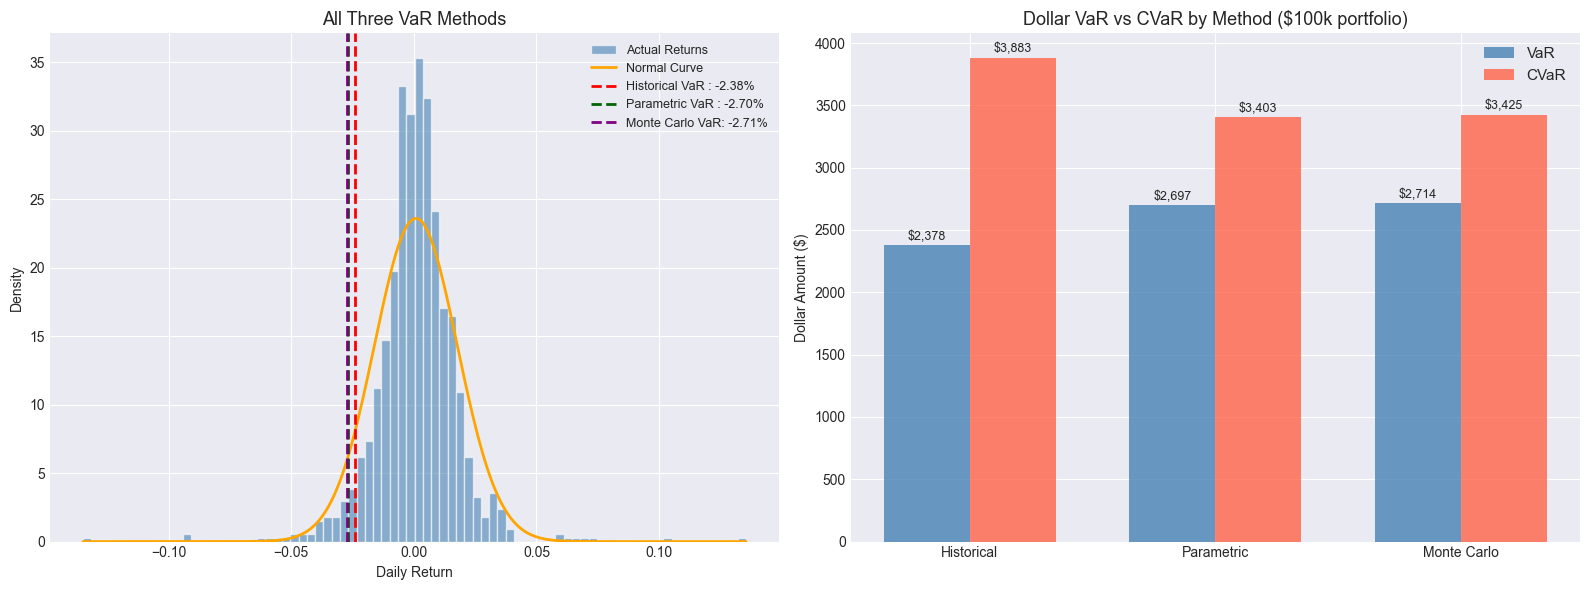

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.linspace(portfolio_r.min(), portfolio_r.max(), 300)

axes[0].hist(portfolio_r, bins=80, density=True,
              color="steelblue", edgecolor="white",
              alpha=0.6, label="Actual Returns")

axes[0].plot(x, norm.pdf(x, mu, sigma), color="orange",
              linewidth=2, label="Normal Curve")

axes[0].axvline(historical_var,  color="red",       linewidth=2,
                 linestyle="--", label=f"Historical VaR : {historical_var*100:.2f}%")
axes[0].axvline(para_var,  color="darkgreen",  linewidth=2,
                 linestyle="--", label=f"Parametric VaR : {para_var*100:.2f}%")
axes[0].axvline(mc_var,          color="purple",     linewidth=2,
                 linestyle="--", label=f"Monte Carlo VaR: {mc_var*100:.2f}%")

axes[0].set_title("All Three VaR Methods", fontsize=13)
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

methods    = ["Historical", "Parametric", "Monte Carlo"]
var_vals   = [portfolio_v*abs(historical_var),
              portfolio_v*abs(para_var),
              portfolio_v*abs(mc_var)]
cvar_vals  = [portfolio_v*abs(cvar),
              dollar_pcvar,
              portfolio_v*abs(mc_cvar)]

x_pos = np.arange(len(methods))
width = 0.35

bars1 = axes[1].bar(x_pos - width/2, var_vals,  width, 
                     label="VaR",  color="steelblue", alpha=0.8)
bars2 = axes[1].bar(x_pos + width/2, cvar_vals, width, 
                     label="CVaR", color="tomato",    alpha=0.8)

axes[1].set_title("Dollar VaR vs CVaR by Method ($100k portfolio)", fontsize=13)
axes[1].set_ylabel("Dollar Amount ($)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(methods)
axes[1].legend(fontsize=11)

# add value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                  f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                  f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../data/phase5_final_comparison.png", dpi=150)
plt.show()